### Astrostatistic Lecture 18

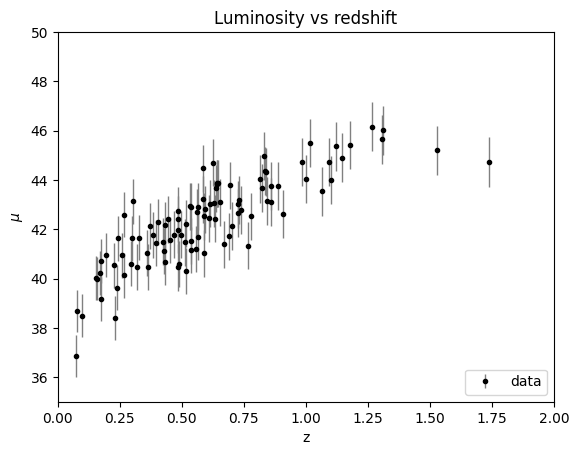

In [4]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
import numpy as np
from tqdm import tqdm
from scipy import stats

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50);

best-fit theta = 0.922505548789121


<ErrorbarContainer object of 3 artists>

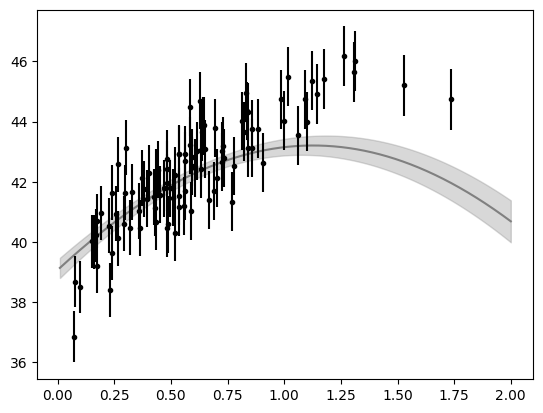

In [42]:
#try to fit the data with GPR
#we make the function pass into the data points
x = z_sample
x_test = np.linspace(0.01, 2, 1000)
y=np.random.normal(mu_sample, 0.1)

kernel = kernels.RBF(1, (0.01, 10.0))
gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, random_state=0)

gp.fit(x[:, None], mu_sample)
predic, predic_err = gp.predict(x_test[:, None], 
                         return_std=True)

print("best-fit theta =", gp.kernel_.theta[0])


plt.plot(x_test, predic, '-', color='gray')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color='gray', alpha=0.3)
plt.errorbar(z_sample, mu_sample , dmu, fmt='.k', ms=6)